#**Análisis Exploratorio de Datos - Explorando el Titanic**

Emiliano Hervert de la Cruz
A01412606

##**Introducción**

El crucero *Titanic* se volvió famoso tras ser el barco más grande que había sido construido hasta el momento y que se hundió tras colisionar con un iceberg. Al convertirse este suceso en una tragedia tan reconocida, resulta interesante analizar datos relacionados con sus pasajeros para encontrar patrones, confirmar suposiciones y/o encontrar relaciones inesperadas entre variables, entre más cosas.

Espero conocer cómo varían mis datos, cómo se relacionan las variables, qué valores faltantes tengo y familiarizarme con la base de datos y sus características. Asimismo, trataré de encontrar cosas interesantes, por ejemplo, si algunas personas tuvieron más probabilidad de sobrevivir que otras.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar datos
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Primeras filas
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#Obtener información básica sobre el data type de las variables y dónde faltan datos
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Para aclarar el significado de algunas variables:
- **Survived** (0 = No sobrevivió, 1 = Sí sobrevivió)
- **Pclass:** Clase del pasajero (1 = Primera clase, 2 = Segunda clase, 3 = Tercera clase)
- **SibSp:** Número de hermanos o cónyuge a bordo
- **Parch:** Número de padres o hijos a bordo
- **Embarked:** Puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton)

##**Parte 1: Variación**

Preguntas:
- ¿La mayoría de personas viajó sola o con algún familiar?
- ¿La tercera clase concentra a la mayoría de los pasajeros? Si no, ¿cuál?
- ¿Cómo está distribuida la edad de los pasajeros? ¿Hay valores atípicos?

###¿La mayoría de personas viajó sola o con algún familiar?

In [4]:
#Crear una variable para "Familiares a bordo"
titanic["Familiares"] = titanic["SibSp"] + titanic["Parch"]

In [5]:
#Contar cuántas personas viajaron solas (True) y cuántas con algún familiar (False)
(titanic["Familiares"] == 0).value_counts()

,count
Familiares,
True,537
False,354


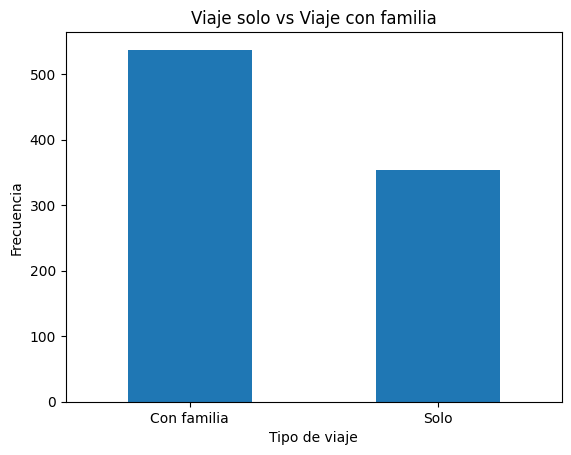

In [6]:
#Graficar resultados para mejor visualización
(titanic["Familiares"] == 0).value_counts().plot(kind="bar")

plt.xticks([0,1], ["Con familia", "Solo"], rotation=0)
plt.title("Viaje solo vs Viaje con familia")
plt.xlabel("Tipo de viaje")
plt.ylabel("Frecuencia")
plt.show()

####Observaciones:
Como se puede observar, la mayoría de los pasajeros del Titanic viajaron junto con al menos un familiar.

Hay muchas conclusiones o interpretaciones que se pueden obtener a partir de esto. Una de ella puede ser que se deba a que el viaje sería muy costoso para una sola persona y aquellos sin pareja o familiares no ganarían lo suficiente como para abordar el barco. Sin embargo, estas suposiciones necesitan de más análisis e incluso más datos como el salario de estas personas para tener un sustento real.

###¿La tercera clase concentra a la mayoría de los pasajeros? Si no, ¿cuál?

In [7]:
#Contar cuántos pasajeros hay en cada clase
titanic["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


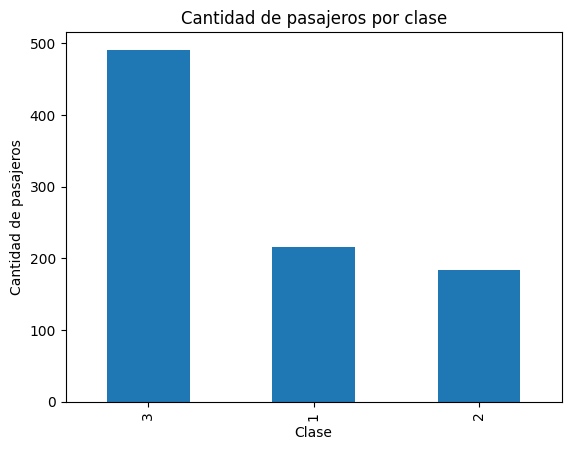

In [8]:
#Graficar resultados para mejor visualización
titanic["Pclass"].value_counts().plot(kind="bar")

plt.title("Cantidad de pasajeros por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de pasajeros")
plt.show()

####Observaciones:
Podemos notar que, en efecto, la tercera clase contiene a la mayoría de los pasajeros. Esto tiene sentido ya que esta corresponde a la clase más baja y, probablemente, más barata, por lo que la mayoría de pasajeros optaron por esta o es la clase más alta que podían pagar. Esto se puede comprobar y sustentar aún más haciendo una comparación entre "Pclass" y "Fare".

###¿Cómo está distribuida la edad de los pasajeros? ¿Hay valores atípicos?

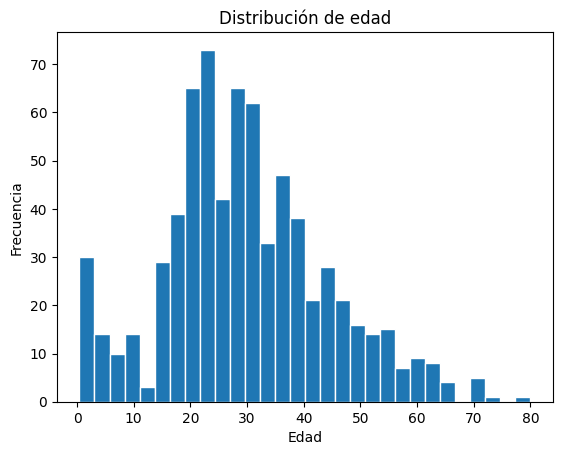

In [9]:
#Crear histograma para ver la distribución de las edades
plt.hist(titanic["Age"].dropna(), bins=30, edgecolor="white")
plt.title("Distribución de edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

<Axes: ylabel='Age'>

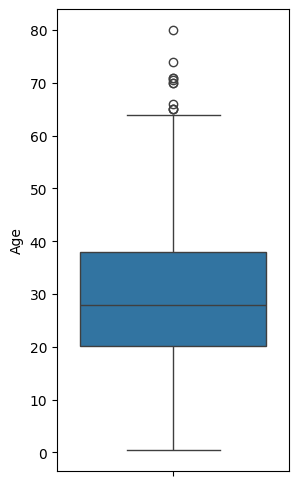

In [10]:
#Boxplot para detectar valores atípicos en las edades
plt.figure(figsize=(3, 6))
sns.boxplot(data=titanic, y="Age")

####Observaciones:
Al observar la distribución de las edades y el boxplot generado, podemos notar que la edad se concentra entre los 20 y 40 años. Asimismo, hay una gran presencia de niños pequeños con edades cercanas a 0.

Sí hay valores atípicos, estos aparecen en las edades después de aproximadamente 65 años.

Es importante tener esto en cuenta, ya que puede relacionarse con las tasas de supervivencia y otras variables. Por ejemplo, las personas con edades mayores pudieron haber tenido más problemas a la hora de evacuar el barco y, por esta razón, no sobrevivieron, por lo que podría llegar a ser útil ignorar estos datos atípicos al comparar los sobrevivientes entre hombres y mujeres, primera y tercera clase, etc.

##**Parte 2: Covariación**

Preguntas:
- ¿Había más hombres que mujeres en primera clase?
- ¿El puerto de embarque pudo influir en la probabilidad de sobrevivir?
- ¿Las personas que viajaban solas tuvieron más probabilidad de sobrevivir **al no tener que preocuparse tanto por familiares**?

###¿Había más hombres que mujeres en primera clase?

In [11]:
#Relación entre ambas variables categóricas
#(Porcentaje de hombres y mujeres en cada clase)
pd.crosstab(titanic["Pclass"], titanic["Sex"], normalize="index")

Sex,female,male
Pclass,,
1,0.435185,0.564815
2,0.413043,0.586957
3,0.293279,0.706721


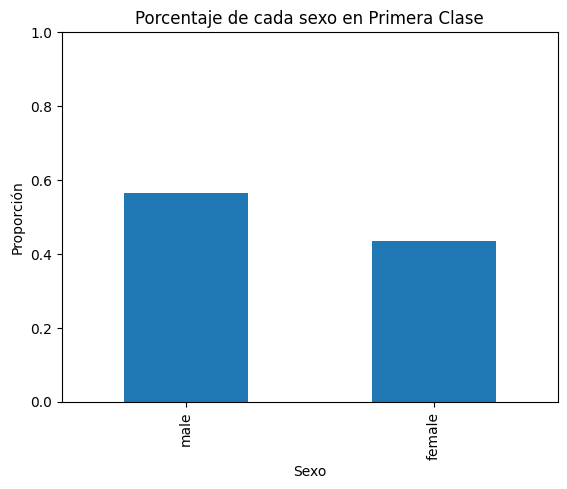

In [12]:
# Filtrar primera clase
primera_clase = titanic[titanic["Pclass"] == 1]

# Calcular proporción dentro de primera clase
primera_clase["Sex"].value_counts(normalize=True).plot(kind="bar")

plt.title("Porcentaje de cada sexo en Primera Clase")
plt.xlabel("Sexo")
plt.ylabel("Proporción")
plt.ylim(0,1)
plt.show()

####Observaciones:
El objetivo de esta pregunta era observar si las desigualdades de género marcaban una diferencia entre quienes entraban a la primera clase del Titanic.

Para contestar esto, podemos ver que el porcentaje de hombres y de mujeres en primera clase es muy similar y no existe una gran diferencia. Sin embargo, al obtener la proporción del sexo para cada una de las clases, se puede notar que en la segunda clase hay una diferencia ligeramente mayor y en la tercera clase la hay un contraste muy grande con un 71% de hombres y 29% de mujeres.

En conclusión, el sexo masculino fue el predominante en todas las clases, especialmente en la clase baja, a diferencia de la primera clase que era lo que se tenía esperado.

###¿El puerto de embarque pudo influir en la probabilidad de sobrevivir?

In [13]:
#Relación entre ambas variables categóricas
 #(Porcentaje de sobrevivientes y no sobrevivientes según cada puerto de embarque)
pd.crosstab(titanic["Embarked"], titanic["Survived"], normalize="index")

Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


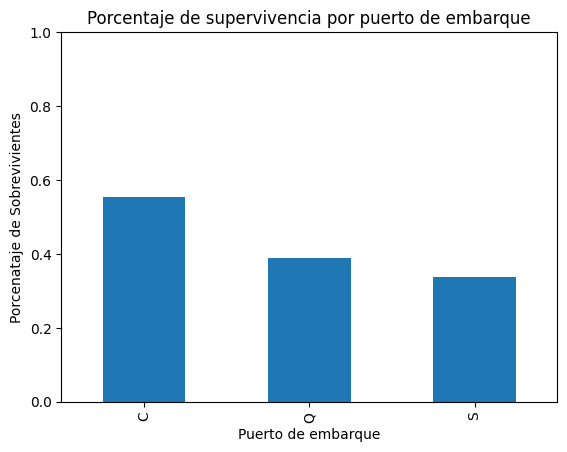

In [14]:
#Graficar porcentaje de sobrevivientes según su puerto de embarque
titanic.groupby("Embarked")["Survived"].mean().plot(kind="bar")

plt.title("Porcentaje de supervivencia por puerto de embarque")
plt.xlabel("Puerto de embarque")
plt.ylabel("Porcenataje de Sobrevivientes")
plt.ylim(0,1)
plt.show()

####Observaciones:
Al visualizar los resultados obtenidos, podemos notar que las personas que abordaron el Titanic en el puerto de Cherbourg tuvieron una ligera mayor probabilidad de sobrevivir cuando, en los demás sitios, la probabilidad de morir es la más alta. Puede parecer que no tenga mucho sentido que el puerto de embarque afecte la supervivencia de los pasajeros siendo que el barco se hundió en medio del Océano Atlántico, pero esto puede indicar que es probable que la gente de este lugar tengan, en su mayoría, alguna característica que los ayudó a sobrevivir.

Si hubo un efecto de 'mujeres y niños primero', puede que en Cherbourg hayan abordado más pasajeras mujeres y/o jóvenes que en otros sitios, si los de primera clase se salvaron más que los demás, Cherbourg puede que tenga una población más adinerada que decidió entrar en esa categoría. Es necesario hacer más análisis para encontrar el por qué de esta relación.

###¿Las personas que viajaban solas tuvieron más probabilidad de sobrevivir?

In [15]:
#Crear una variable para "Solo" (Verdadero o Falso)
titanic["Solo"] = titanic["Familiares"] == 0

In [16]:
#Relación entre ambas variables categóricas
#(Porcentaje de sobrevivientes y no sobrevivientes para quienes viajaron solos y en familia)
pd.crosstab(titanic["Solo"], titanic["Survived"], normalize="index")

Survived,0,1
Solo,,
False,0.494350,0.505650
True,0.696462,0.303538


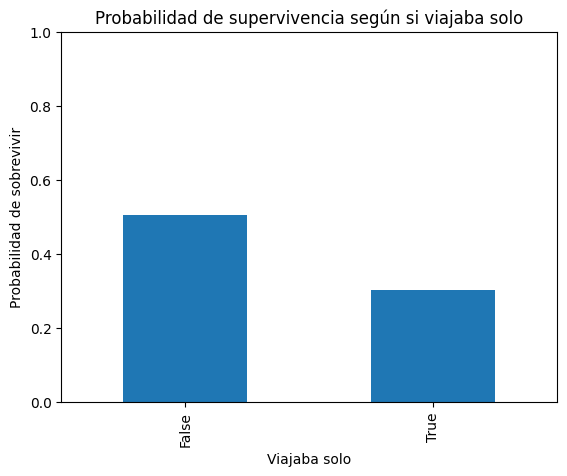

In [17]:
#Graficar porcentaje de sobrevivientes para pasajeros que viajaban solos vs pasajeros que viajaban en familia
titanic.groupby("Solo")["Survived"].mean().plot(kind="bar")

plt.title("Probabilidad de supervivencia según si viajaba solo")
plt.xlabel("Viajaba solo")
plt.ylabel("Probabilidad de sobrevivir")
plt.ylim(0,1)
plt.show()

##**Parte 3: Valores faltantes**

Es necesario identificar los valores faltantes y limpiar los datos ya que, los análisis que podamos hacer pueden ser incorrectos o poco representativos. Asimismo, al crear modelos y utilizar machine learning, los valores faltantes no son compatibles con algunos algoritmos.

In [18]:
#Inspeccionar valores faltantes
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Aquí podemos notar que hay varios valores faltantes en la variable Age, muchos en la variable Cabin y solamente 2 en Embarked.

<Axes: >

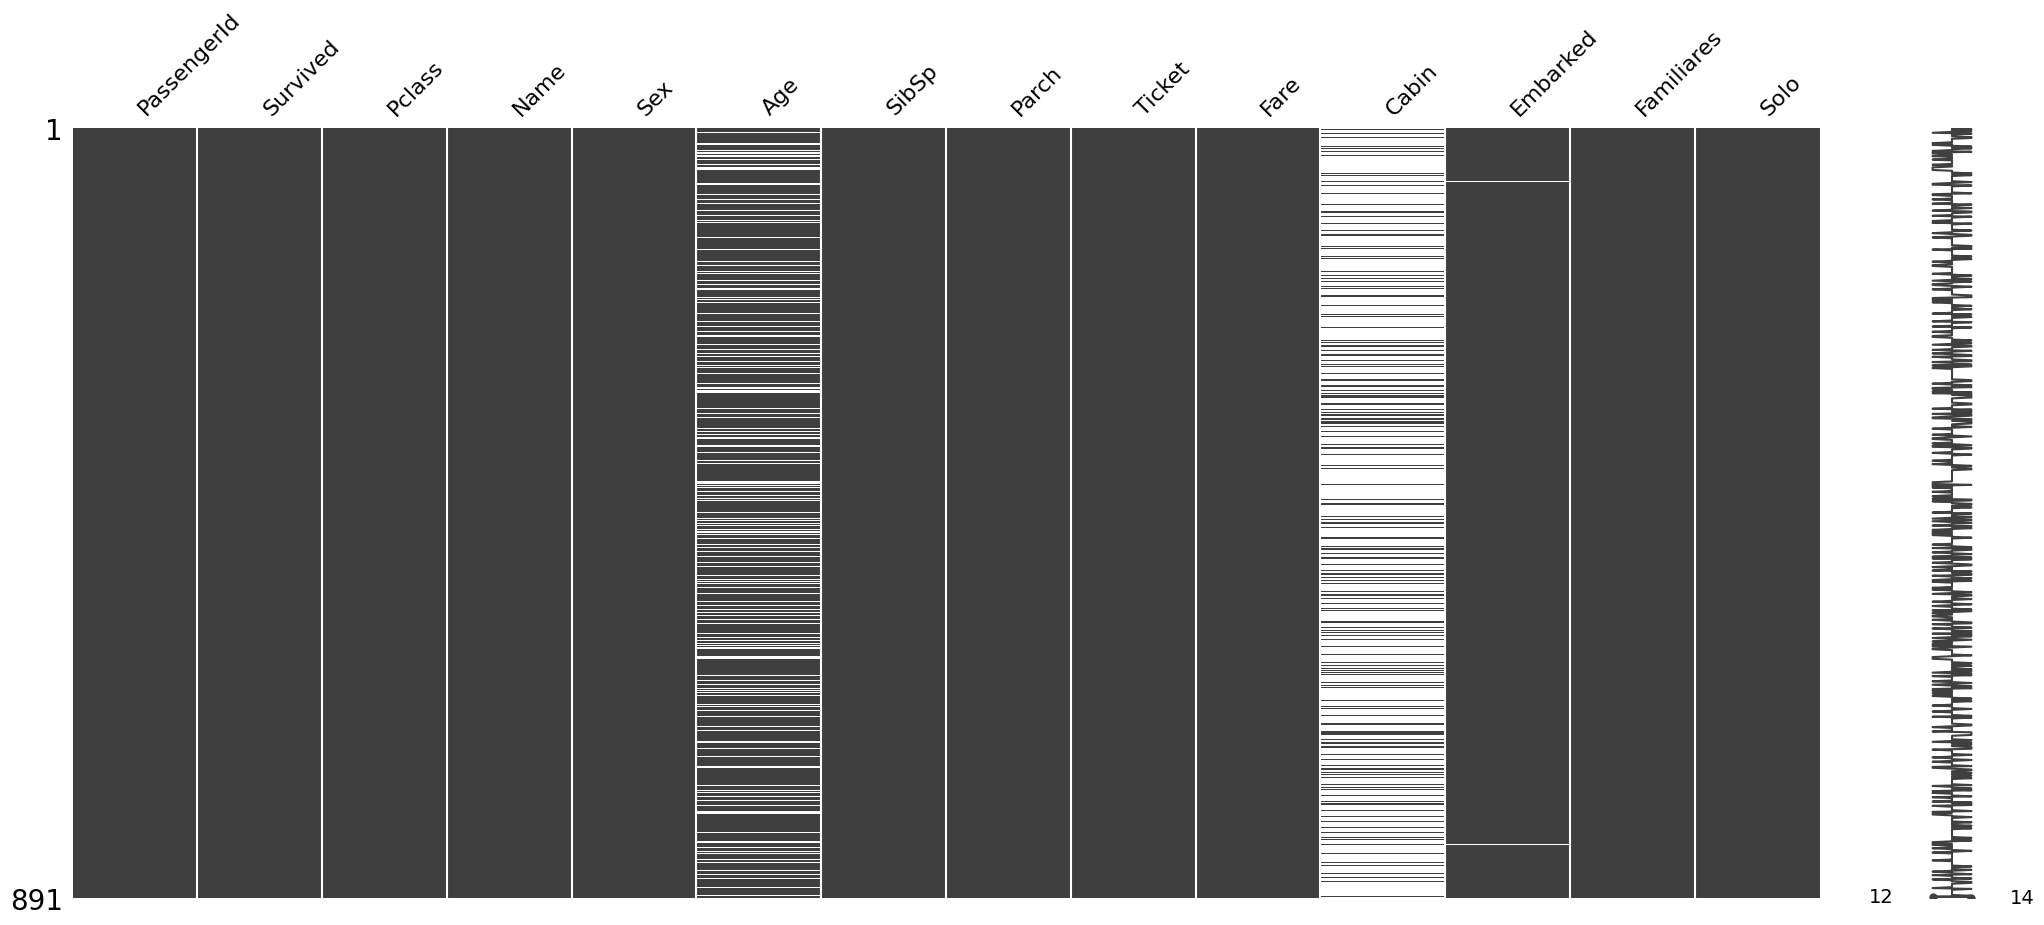

In [19]:
# Visualizar patrón de valores faltantes
import missingno as msno

msno.matrix(titanic)

Teniendo en cuenta el contexto real del Titanic, es posible que los errores de medición y huecos en los datos pertenezcan a pasajeros de clases bajas. Hay que comprobar esto:

<Axes: >

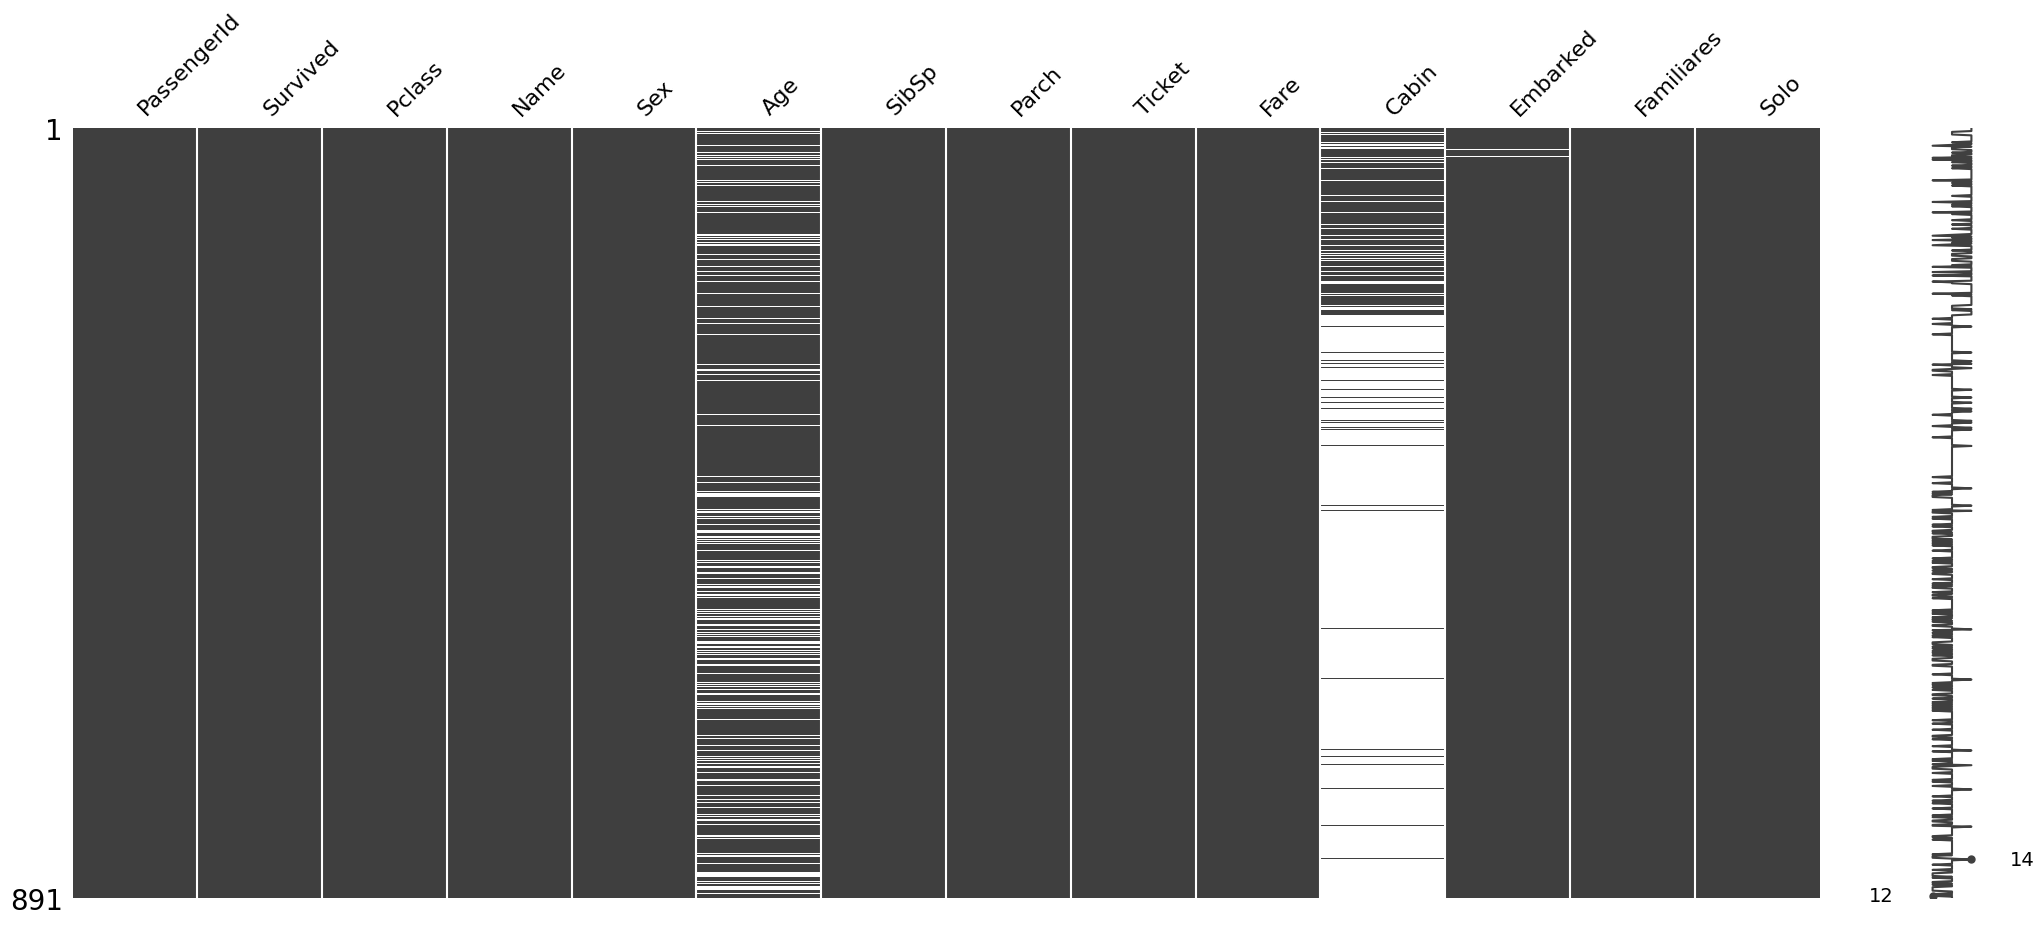

In [20]:
por_clase = titanic.sort_values('Pclass', ascending=True)
msno.matrix(por_clase)

Al ordenar las filas según la clase (primera, segunda y, por último, tercera), podemos ver que los datos faltantes en Cabin son pocos al inicio y después aumentan, por lo que se suelen perder más datos mientras más baja sea la clase del pasajero. Para las edades no vemos un patrón claro y para Embarked solamente hay 2 valores faltantes, por lo que no se puede identificar uno tampoco.

¿Cómo tratar los datos faltantes?
- Debido a que hay pocos datos faltantes de Embarked, pueden eliminarse esas 2
filas sin problema alguno.
- Los datos de Cabin suelen ser diferentes para cada pasajero y no nos dan información muy relevante. Es posible identificar si hay familiares al notar que pasajeros comparten la misma cabina, pero ya tenemos otra variable que se encarga de eso, por lo que podríamos eliminar completamente esta columna.
- Hay muchos valores faltantes en Age y no podemos eliminar la columna ya que es un dato valioso, una forma de manejar los valores faltantes sería darles el valor del promedio de edad.

##**Parte 4: Pregunta propia**

Pregunta:
- ¿El efecto de viajar en familia y la supervivencia dependía del género del pasajero?

In [21]:
##Porcentaje de sobrevivientes y no sobrevivientes por Sexo y según si viajaban solos o no
titanic.groupby(["Sex", "Solo"])["Survived"].mean()

Sex     Solo 
female  False    0.712766
        True     0.785714
male    False    0.271084
        True     0.155718
Name: Survived, dtype: float64

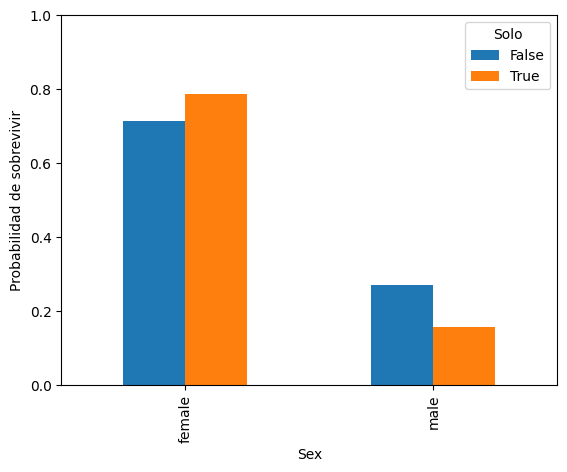

In [22]:
#Visualizar gráficamente los resultados anteriores
titanic.groupby(["Sex", "Solo"])["Survived"].mean().unstack().plot(kind="bar")

plt.ylabel("Probabilidad de sobrevivir")
plt.ylim(0,1)
plt.show()

####Observaciones:
No hay tanta diferencia entre la supervivencia y si se viajaba solo para las mujeres; sin embargo, para los hombres, esta diferencia fue mayor.

En hombres, viajar acompañado aumentó considerablemente la probabilidad de supervivencia, mientras que en mujeres la diferencia fue menor. Esto sugiere que el efecto de viajar en familia dependía del género del pasajero.

##**Reflexión final**

Con este trabajo, aprendí sobre las ventajas que tiene hacer un Análisis Exploratorio de Datos al empezar a trabajar con un nuevo proyecto o un nuevo dataset. Pude observar características importantes e interesantes sobre las variables y los datos, me familiarizé con los data types utilizados y reconocí los valores faltantes.

Con esto, veo que es posible tener un mejor punto de arranque para lo demás que se vaya a hacer con el dataset y el uso que se le de a los datos, se tienen identificados los valores faltantes a reemplazar o eliminar y se tienen vistos algunos puntos de partida que requieren una investigación más profunda para hacer hallazgos importantes, como puede ser encontrar el por qué Cherbourg tuvo más sobrevivientes que los otros puertos de embarque o al menos acercarse a la(s) posible(s) respuesta(s).